<a href="https://colab.research.google.com/github/sheliabond/Prescriptive-Analytics---Spring-2026-Public-/blob/main/Assignments/Assignment%204/Scheduling%20in%20Your%20Domanin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scheduling in Your Domain

**Assignment 04 - Lesson 9: Scheduling and Time-Based Decisions**  
**Student Name:** Shelia
**Date:** 04/08/2026  
**Chosen context:** Retail/Service - Restaurant Staffing

---

## Introduction

In this assignment, you will model a scheduling problem in your own domain. You will define time periods, demand coverage requirements, and a cost objective, then build and solve a PuLP model. You will also create one schedule visualization, analyze a cost-vs-service tradeoff, and respond to one stakeholder change.

This assignment is intentionally focused. It should be lighter than the Midterm while still demonstrating practical scheduling skills you can explain to a manager.

In [2]:
# Install required packages (if needed in Colab)
# Skip if running locally and packages are already installed
%pip install pulp pandas matplotlib -q

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pulp import LpProblem, LpMinimize, LpMaximize, LpVariable, lpSum, value, LpStatus
import io

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1 - Choose Your Domain and Scheduling Problem

The scheduling decision for the launch of All Day Breakfast at McDonald's involves assigning staff to handle food preparation, order taking, and customer service throughout the day. The time periods include breakfast, lunch, dinner, and overnight shifts to ensure continuous availability of menu items. The main objective is to maintain a high service level by aligning staffing with customer demand, ensuring fast service and consistent quality during the rollout of the new offering.

## Section 2 - Define the Schedule Structure



### 2.1 LLM Steps for Synthetic Data

I used an LLM to generate sample staffing data, which produced estimated demand requirements and cost per unit for seven time periods throughout the day.

In [4]:
csv_string = '''
time_period,demand_required,cost_per_unit
P1,4,18
P2,5,18
P3,6,20
P4,7,22
P5,6,21
P6,5,19
P7,4,17
'''
schedule_df = pd.read_csv(io.StringIO(csv_string))

In [ ]:
# Update time_period column with more descriptive names
time_period_mapping = {
    'P1': '4am-8am',
    'P2': '8am-11am',
    'P3': '11am-2pm',
    'P4': '2pm-5pm',
    'P5': '5pm-8pm',
    'P6': '8pm-11pm',
    'P7': '11pm-4am'
}
schedule_df['time_period'] = schedule_df['time_period'].map(time_period_mapping)
display(schedule_df)

,time_period,demand_required,cost_per_unit
0,4am-8am,4,18
1,8am-11am,5,18
2,11am-2pm,6,20
3,2pm-5pm,7,22
4,5pm-8pm,6,21
5,8pm-11pm,5,19
6,11pm-4am,4,17


In [5]:

structure_df = pd.DataFrame([
    {"item": "Resources being scheduled", "definition": "Restaurant staff (employees)"},
    {"item": "Time unit", "definition": "3-4 hour shift blocks"},
    {"item": "Coverage meaning", "definition": "Number of staff required to meet customer demand and service levels"},
    {"item": "Objective", "definition": "Maintaining high service level"}
])
structure_df

,item,definition
0,Resources being scheduled,Restaurant staff (employees)
1,Time unit,3-4 hour shift blocks
2,Coverage meaning,Number of staff required to meet customer dema...
3,Objective,Maintaining high service level


## Section 3 - Build and Solve the Scheduling Model

Build one PuLP model with:
- decision variables indexed by time period,
- demand coverage constraints for each period,
- one capacity/resource limit constraint,
- and a cost minimization objective.

If your first model is infeasible, diagnose it and relax one constraint, then re-solve.

In [6]:
# Build and solve the base scheduling model
# Decision variable: units scheduled in each period (continuous, nonnegative)
periods = schedule_df["time_period"].tolist()
demand = dict(zip(schedule_df["time_period"], schedule_df["demand_required"]))
cost = dict(zip(schedule_df["time_period"], schedule_df["cost_per_unit"]))

# TODO: Replace with a domain-appropriate capacity limit
total_capacity_limit = int(schedule_df["demand_required"].sum() * 1.15)

base_model = LpProblem("Scheduling_Base", LpMinimize)
scheduled = {p: LpVariable(f"scheduled_{p}", lowBound=0) for p in periods}

# Objective: minimize total scheduling cost
base_model += lpSum([scheduled[p] * cost[p] for p in periods]), "Total_Cost"

# Coverage constraints: scheduled units must meet period demand
for p in periods:
    base_model += scheduled[p] >= demand[p], f"Coverage_{p}"

# Capacity/resource limit constraint (single aggregate limit)
base_model += lpSum([scheduled[p] for p in periods]) <= total_capacity_limit, "Total_Capacity"

base_model.solve()

print(f"Status: {LpStatus[base_model.status]}")
print(f"Total cost: {value(base_model.objective):.2f}")

base_solution_df = pd.DataFrame({
    "time_period": periods,
    "demand_required": [demand[p] for p in periods],
    "scheduled_base": [value(scheduled[p]) for p in periods],
    "cost_per_unit": [cost[p] for p in periods]
})
display(base_solution_df)

Status: Optimal
Total cost: 725.00


,time_period,demand_required,scheduled_base,cost_per_unit
0,P1,4,4.0,18
1,P2,5,5.0,18
2,P3,6,6.0,20
3,P4,7,7.0,22
4,P5,6,6.0,21
5,P6,5,5.0,19
6,P7,4,4.0,17


### 3.1 Interpret the Base Schedule
The base schedule matches staffing exactly to demand in each time period, so capacity is very tight with no extra buffer. The hardest period to cover is 2pm to 5pm, which is unusual since it is not typically a peak time but has the highest staffing requirement and cost. A manager would care because this could indicate inefficiency, where costs may be too high compared to demand, and may want to review or adjust staffing for that period.

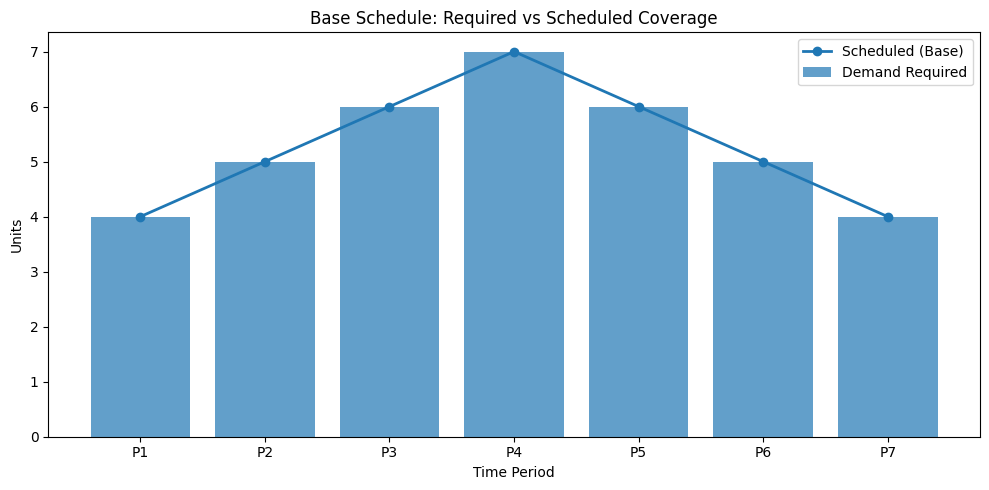

In [7]:
# Visualization: coverage chart (scheduled vs required)
# You may replace this with a Gantt-style chart if preferred.
plt.figure(figsize=(10, 5))
x = range(len(base_solution_df))
plt.bar(x, base_solution_df["demand_required"], alpha=0.7, label="Demand Required")
plt.plot(x, base_solution_df["scheduled_base"], marker="o", linewidth=2, label="Scheduled (Base)")
plt.xticks(x, base_solution_df["time_period"])
plt.xlabel("Time Period")
plt.ylabel("Units")
plt.title("Base Schedule: Required vs Scheduled Coverage")
plt.legend()
plt.tight_layout()
plt.show()

## Section 4 - Cost vs Service Tradeoff Analysis

Run one what-if scenario and compare against your base model.

Examples:
- tighter budget/capacity,
- higher coverage requirement,
- changed period demand pattern.

In [ ]:
# What-if scenario: higher service requirement (10% increase in required coverage)
# TODO: You may change this to another valid cost-vs-service scenario.
service_multiplier = 1.10
demand_tradeoff = {p: demand[p] * service_multiplier for p in periods}

tradeoff_model = LpProblem("Scheduling_Tradeoff", LpMinimize)
scheduled_tradeoff = {p: LpVariable(f"scheduled_tradeoff_{p}", lowBound=0) for p in periods}

tradeoff_model += lpSum([scheduled_tradeoff[p] * cost[p] for p in periods]), "Total_Cost_Tradeoff"

for p in periods:
    tradeoff_model += scheduled_tradeoff[p] >= demand_tradeoff[p], f"Coverage_tradeoff_{p}"

# Keep same capacity limit for comparison
tradeoff_model += lpSum([scheduled_tradeoff[p] for p in periods]) <= total_capacity_limit, "Total_Capacity_Tradeoff"
tradeoff_model.solve()

tradeoff_solution_df = pd.DataFrame({
    "time_period": periods,
    "scheduled_tradeoff": [value(scheduled_tradeoff[p]) for p in periods]
})

comparison_df = base_solution_df[["time_period", "demand_required", "scheduled_base"]].merge(
    tradeoff_solution_df, on="time_period", how="left"
)

base_cost = value(base_model.objective)
tradeoff_cost = value(tradeoff_model.objective)

print(f"Base status: {LpStatus[base_model.status]} | Base total cost: {base_cost:.2f}")
print(f"Tradeoff status: {LpStatus[tradeoff_model.status]} | Tradeoff total cost: {tradeoff_cost:.2f}")
display(comparison_df)

**Prompt:** In 2-4 sentences for a non-technical manager, explain the cost-vs-service tradeoff shown by your base and what-if results.

[TODO: Your plain-language explanation here.]

## Section 5 - Stakeholder Change and Reflection

Choose one stakeholder change:
- **(a)** Fairness constraint: no single period receives more than X% of total scheduled load.
- **(b)** Higher minimum coverage floor than base requirement.
- **(c)** Change objective from cost minimization to service maximization.

Update your model, solve, and compare with one visualization.

In [ ]:
# Stakeholder change example: fairness constraint
# You may replace this with option (b) or (c), but keep one stakeholder change only.
fairness_share = 0.30  # TODO: choose your fairness threshold

stakeholder_model = LpProblem("Scheduling_Stakeholder_Change", LpMinimize)
scheduled_stakeholder = {p: LpVariable(f"scheduled_stakeholder_{p}", lowBound=0) for p in periods}

stakeholder_model += lpSum([scheduled_stakeholder[p] * cost[p] for p in periods]), "Total_Cost_Stakeholder"

for p in periods:
    stakeholder_model += scheduled_stakeholder[p] >= demand[p], f"Coverage_stakeholder_{p}"

total_scheduled = lpSum([scheduled_stakeholder[p] for p in periods])
stakeholder_model += total_scheduled <= total_capacity_limit, "Total_Capacity_Stakeholder"

# Fairness: no period can exceed a share of total scheduled load
for p in periods:
    stakeholder_model += scheduled_stakeholder[p] <= fairness_share * total_scheduled, f"Fairness_{p}"

stakeholder_model.solve()

stakeholder_solution_df = pd.DataFrame({
    "time_period": periods,
    "scheduled_stakeholder": [value(scheduled_stakeholder[p]) for p in periods]
})

final_compare_df = comparison_df.merge(stakeholder_solution_df, on="time_period", how="left")
print(f"Stakeholder status: {LpStatus[stakeholder_model.status]}")
if stakeholder_model.status == 1:
    print(f"Stakeholder total cost: {value(stakeholder_model.objective):.2f}")
display(final_compare_df)

In [ ]:
# Comparison visualization: base vs stakeholder-change schedule
plt.figure(figsize=(10, 5))
x = range(len(final_compare_df))
plt.plot(x, final_compare_df["scheduled_base"], marker="o", linewidth=2, label="Base")
plt.plot(x, final_compare_df["scheduled_stakeholder"], marker="s", linewidth=2, label="Stakeholder Change")
plt.xticks(x, final_compare_df["time_period"])
plt.xlabel("Time Period")
plt.ylabel("Scheduled Units")
plt.title("Schedule Comparison: Base vs Stakeholder Change")
plt.legend()
plt.tight_layout()
plt.show()

### 5.1 Stakeholder Change Interpretation

**Prompt:** In 1-2 short paragraphs, describe what changed between the base and stakeholder-change solutions and why that matters for decision-making.

[TODO: Your interpretation here.]

### 5.2 Professional Reflection

**Prompt:** Write a 2-3 paragraph professional reflection that covers:
- what changed in your model and results,
- why that change matters in your domain,
- and one thing you learned about how time-based scheduling constraints differ from earlier allocation problems.

Write this as if briefing a manager or project sponsor.

[TODO: Your reflection here.]

---
## Expectations: What to Check Before Submitting

Run through this checklist before you submit:

- **Model execution:** Base model and stakeholder-change model run without errors; infeasibility is handled clearly if encountered.
- **Visualization quality:** At least one schedule visualization has clear title, axis labels, and is referenced in your text.
- **Stakeholder section complete:** One stakeholder change implemented, solved, and compared to base.
- **Writing quality:** Clear, professional, non-technical explanation where requested; no leftover bare `[TODO]` in final submission.
- **GitHub readiness:** Notebook is committed, repository link is accessible, and materials are organized.

The rubric used for grading is provided separately.